# Aprendizaje supervisado

El aprendizaje supervisado es un tipo de aprendizaje automático en el que un algoritmo aprende de un conjunto de datos etiquetados para predecir resultados o clasificar datos

## Pasos a seguir:
0. Recopilar datos historicos con etiquetas
1. Crear conjunto de datos de entrenamiento y prueba:
Se proporciona al algoritmo un conjunto de datos de entrenamiento (X_Train) junto con las etiquetas correspondientes (y_train).
2. Selección del modelo:
Escoge el modelo apropiado dependiendo del conjunto de datos y el problema a solucionar.
3. Entrenar el modelo:
El algoritmo analiza los datos y ajusta sus parámetros internos para aprender la relación entre las características de entrada y las etiquetas.
4. Predicción:
Una vez entrenado, usar el conjunto de datos de prueba (X_test)
y predecir la salida, basándose en lo aprendido (y_pred)
5. Evaluar el modelo:
Comparar estas predicciones con las etiquetas correspondientes del conjunto de prueba (y_pred vs y_test)
---



## 1. Clasificación
La clasificación es un tipo de aprendizaje supervisado donde el objetivo es predecir una etiqueta o categoría para una nueva observación basándose en datos previos.

- Ejemplos cotidianos:

  - Clasificación de correos electrónicos como spam o no spam.
  - Diagnóstico médico basado en análisis clínicos.
  - Predicción de aprobación o rechazo de un crédito bancario.

### 1.1. Tipos de Clasificación

- Binaria: Dos clases posibles (ejemplo: spam o no spam).

- Multiclase: Múltiples clases sin superposición (ejemplo: clasificación de marcas de automóviles).

- Multietiqueta / MultiLabel: Cada observación puede pertenecer a varias clases al mismo tiempo (ejemplo: categoría de géneros de películas en una plataforma de streaming).

---
### Librerias a usar:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# 2. Carga y exploración de datos
https://scikit-learn.org/stable/datasets/toy_dataset.html#wine-recognition-dataset

In [2]:
from sklearn.datasets import load_wine

data = load_wine()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print("Primera vista del dataset:")
display(df.head())
print("\nInformación del dataset:")
df.info()
print("\nDistribución de la variable objetivo:")
print(df['target'].value_counts())


Primera vista del dataset:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0



Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    flo

- Visualización básica de la distribución de las clases del dataset

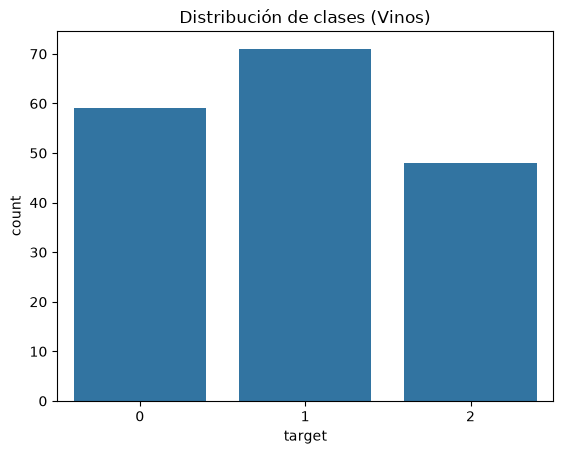

In [3]:
sns.countplot(x='target', data=df)
plt.title('Distribución de clases (Vinos)')
plt.show()

# 3. Preprocesamiento

Alistar mis datos para que el modelo de ML los pueda usar para entrenar, descubrir patrones y luego predecir

In [4]:
# X: Conjunto de caracteristicas
# y: Variable Objetivo
X = df.drop('target', axis=1)
y = df['target']

# División en conjuntos de entrenamiento y prueba (usa stratify para respetar proporción de clases)

#### Random state: Es un valor de aleatoriedad fijo. Si usas el mismo random_state, obtendrás la misma división cada vez que ejecutes el código.
#### stratify: Asegura que la proporción de clases en el conjunto de entrenamiento y prueba sea similar a la del dataset original. 
#### Esto es especialmente importante si las clases están desbalanceadas.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)

# Escalado (muy importante para algunos modelos como KNN y SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Pregunta: ¿Por qué normalizamos los datos?

# 4. Entrenamiento de modelos

## 4.1. Modelos de Clasificación

A continuación, se presentan algunos de los modelos de clasificación más utilizados:

### 4.1.1 Regresión Logística

Modelo estadístico que estima la probabilidad de pertenencia a una clase.

- Ventaja: Simple y rápido de entrenar.
- Ejemplo de uso: Predicción de fraude en transacciones bancarias.
- Referencias: https://www.youtube.com/watch?v=EKm0spFxFG4

### 4.1.2 K-Nearest Neighbors (KNN)

Clasifica un punto basándose en la mayoría de sus vecinos más cercanos.

- Ventaja: Intuitivo y sin suposiciones sobre los datos.
- Ejemplo de uso: Clasificación de apps móviles en categorías según su uso.
- Referencias: https://www.youtube.com/watch?v=0p0o5cmgLdE

### 4.1.3 Árboles de Decisión

Modelo basado en reglas de decisiones para realizar la clasificación.

- Ventaja: Fácil de interpretar.
- Ejemplo de uso: Aprobar o rechazar créditos bancarios.
- Referencias:
  - https://www.youtube.com/watch?v=JcI5E2Ng6r4&t
  - https://www.youtube.com/watch?v=32-eBE9-4zc&t

### 4.1.4 Random Forest

Conjunto de múltiples árboles de decisión que mejoran la precisión.

- Ventaja: Reduce el sobreajuste.
- Ejemplo de uso: Clasificación de clientes para ofertas personalizadas.
- Referencias: https://www.youtube.com/watch?v=VfMPslt2wgA

### 4.1.5 Support Vector Machines (SVM)

Encuentra el hiperplano óptimo para separar las clases.

- Ventaja: Funciona bien en datos no lineales.
- Ejemplo de uso: Clasificación de tipos de automóviles según características.
- Referencias:
 - https://www.youtube.com/watch?v=jo9slrXKKNo
 - https://www.youtube.com/watch?v=_YPScrckx28

### 4.1.6. Naive Bayes

Basado en la teoría de probabilidad de Bayes, asume independencia entre variables.

 - Ventaja: Eficiente con grandes volúmenes de datos.
 - Ejemplo de uso: Clasificación de opiniones en reseñas de productos (positiva/negativa).
 - Referencias:
   - https://www.youtube.com/watch?v=oQ1OyqvL7dQ
   - https://youtu.be/O2L2Uv9pdDA?t=68

### Tabla Comparativa de Modelos
| Modelo | Cómo Funciona | Casos de Uso |
|--------|---------------|--------------|
| **Regresión Logística** | Calcula probabilidad usando función sigmoide | Clasificación lineal - clasificación binaria, buen baseline |
| **K-Vecinos Más Cercanos (KNN)** | Busca vecinos más similares en el espacio de características | Datos pequeños, relaciones complejas no lineales |
| **Árboles de Decisión** | Divide datos con reglas jerárquicas | Datos interpretables, relaciones no lineales |
| **Random Forest** | Combina múltiples árboles (ensamble) | Datos complejos, alto rendimiento general |
| **SVM (Máquinas de Vectores Soporte)** | Encuentra hiperplano óptimo entre clases | Datos de alta dimensión, márgenes claros |
| **Naive Bayes** | Usa probabilidad bayesiana con supuesto de independencia | Text mining, datos con muchas features |

## 4.2 Ejemplos Prácticos

### 4.2.1 Escoger el modelo

In [5]:
from sklearn.naive_bayes import GaussianNB


clasificadorNaiveBayes = GaussianNB()
clasificadorNaiveBayes

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


### 4.2.2 Entrenar el modelo

In [6]:
clasificadorNaiveBayes.fit(X_train_scaled,y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](3,)","[53.,64.,43.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](3,)","[0.33,0.4 ,0.27]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](3,)","[0,1,2]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1e-09
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](3, 13)","[[ 0.93,-0.26, 0.3 ,..., 0.42, 0.78, 1.16], [-0.87,-0.39,-0.42,..., 0.48, 0.22,-0.71], [ 0.15, 0.9 , 0.25,...,-1.23,-1.29,-0.38]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](3, 13)","[[0.33,0.41,0.67,...,0.23,0.26,0.51], [0.46,0.8 ,1.35,...,0.77,0.51,0.26], [0.41,0.9 ,0.45,...,0.23,0.15,0.15]]"


### 4.2.3 Predecir sobre los datos de Prueba

In [7]:
y_pred = clasificadorNaiveBayes.predict(X_test_scaled)
y_pred

array([0, 2, 2, 1, 1, 2, 1, 0, 2, 1, 0, 1, 0, 1, 1, 0, 0, 2])

In [8]:
y_test_df = pd.DataFrame(y_test.reset_index(drop=True))

In [9]:
X_test.reset_index(drop=True).merge(y_test_df, left_index=True, right_index=True).merge(pd.DataFrame(y_pred, columns=['predicted']), left_index=True, right_index=True)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,predicted
0,13.88,1.89,2.59,15.0,101.0,3.25,3.56,0.17,1.70,5.43,0.88,3.56,1095.0,0,0
1,12.86,1.35,2.32,18.0,122.0,1.51,1.25,0.21,0.94,4.10,0.76,1.29,630.0,2,2
2,13.78,2.76,2.30,22.0,90.0,1.35,0.68,0.41,1.03,9.58,0.70,1.68,615.0,2,2
3,12.22,1.29,1.94,19.0,92.0,2.36,2.04,0.39,2.08,2.70,0.86,3.02,312.0,1,1
4,12.42,2.55,2.27,22.0,90.0,1.68,1.84,0.66,1.42,2.70,0.86,3.30,315.0,1,1
5,13.45,3.70,2.60,23.0,111.0,1.70,0.92,0.43,1.46,10.68,0.85,1.56,695.0,2,2
6,13.11,1.01,1.70,15.0,78.0,2.98,3.18,0.26,2.28,5.30,1.12,3.18,502.0,1,1
7,13.87,1.90,2.80,19.4,107.0,2.95,2.97,0.37,1.76,4.50,1.25,3.40,915.0,0,0
8,14.13,4.10,2.74,24.5,96.0,2.05,0.76,0.56,1.35,9.20,0.61,1.60,560.0,2,2
9,12.04,4.30,2.38,22.0,80.0,2.10,1.75,0.42,1.35,2.60,0.79,2.57,580.0,1,1


### 4.2.4 Validación del modelo

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         7
           2       1.00      1.00      1.00         5

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



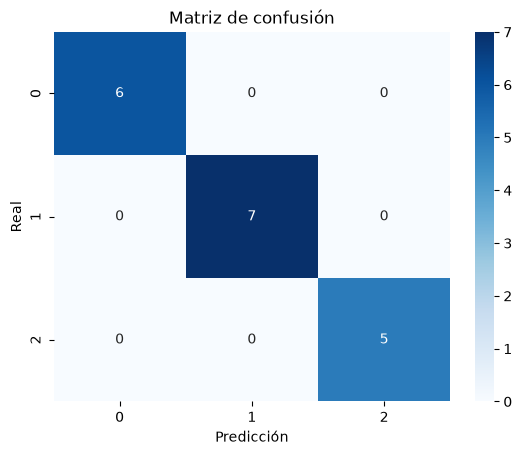

In [10]:
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Matriz de confusión')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

### 4.2.4 Probar el modelo (OPCIONAL)

In [11]:
vino_prueba = np.array([[458, 
                         2.77, 
                         2.51, 
                         18.5, 
                         101.0, 
                         2.85, 
                         3.27, 
                         5, 
                         2.03,
                         5.04, 
                         1.06, 
                         3.33,
                         820.0]])

vino_prueba_scaled = scaler.transform(vino_prueba)
resultado = clasificadorNaiveBayes.predict(vino_prueba_scaled)
resultado


C:\Users\cdsc3\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([1])

### Probar con varios modelos:


KNN - Accuracy: 1.0000 | F1 Macro: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         7
           2       1.00      1.00      1.00         5

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



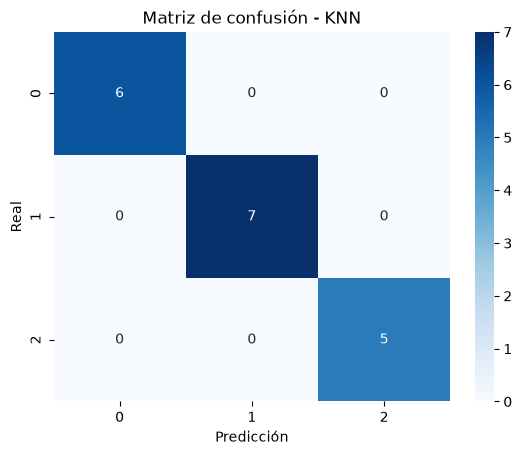


Decision Tree - Accuracy: 0.9444 | F1 Macro: 0.9475
              precision    recall  f1-score   support

           0       1.00      0.83      0.91         6
           1       0.88      1.00      0.93         7
           2       1.00      1.00      1.00         5

    accuracy                           0.94        18
   macro avg       0.96      0.94      0.95        18
weighted avg       0.95      0.94      0.94        18



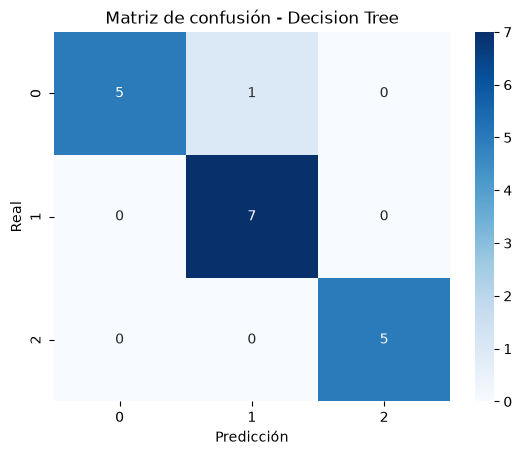


Random Forest - Accuracy: 1.0000 | F1 Macro: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         7
           2       1.00      1.00      1.00         5

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



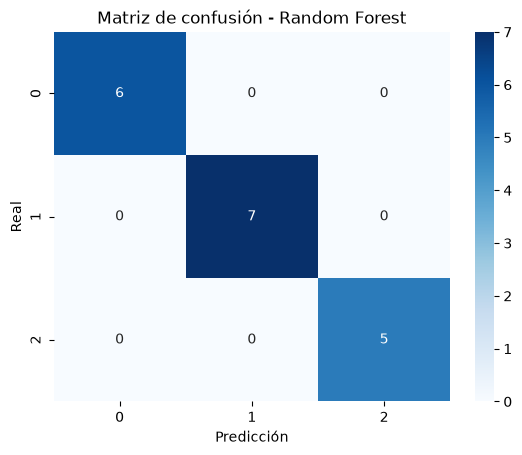

C:\Users\cdsc3\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



SVC (Linear) - Accuracy: 1.0000 | F1 Macro: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         7
           2       1.00      1.00      1.00         5

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



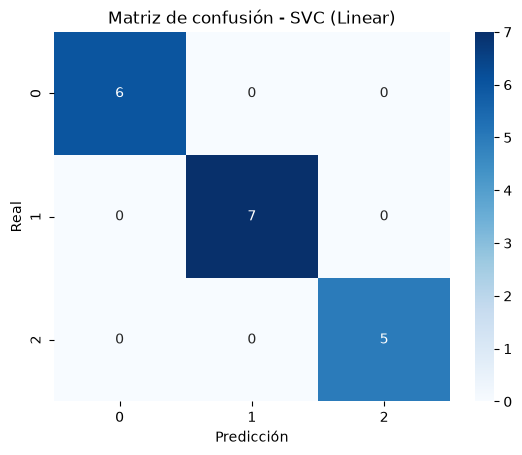

In [12]:
models = {
    "KNN": KNeighborsClassifier(), ## K = Raiz cuadradada de N
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVC (Linear)": SVC(kernel='linear', probability=True, random_state=42),
}
results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train) # ENTRENAR
    y_pred = model.predict(X_test_scaled) # PREDICCION
    # EVALUAR MODELO
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    results[name] = {
        "model": model,
        "accuracy": acc,
        "f1_macro": f1_macro,
        "y_pred": y_pred
    }
    print(f"\n{name} - Accuracy: {acc:.4f} | F1 Macro: {f1_macro:.4f}")
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de confusión - {name}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()

# 5. Comparación visual de modelos

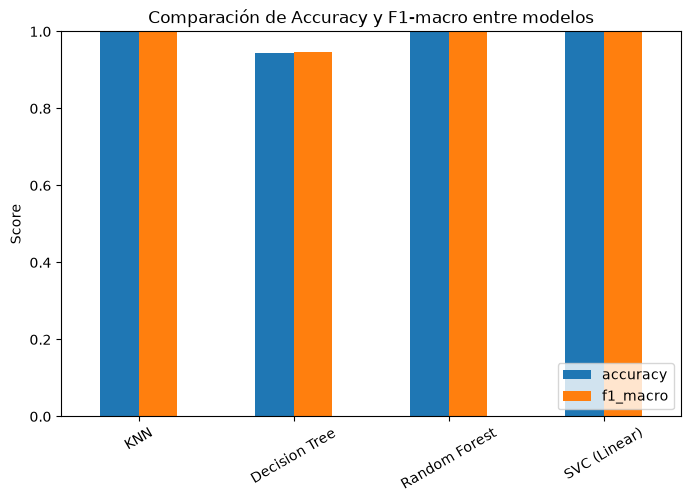

In [13]:
metricas = pd.DataFrame({
    'accuracy': {name: res['accuracy'] for name, res in results.items()},
    'f1_macro': {name: res['f1_macro'] for name, res in results.items()}
})

metricas.plot(kind='bar', figsize=(8,5))
plt.title('Comparación de Accuracy y F1-macro entre modelos')
plt.ylabel('Score')
plt.ylim(0,1)
plt.xticks(rotation=30)
plt.legend(loc='lower right')
plt.show()

# ¿Por qué es útil comparar F1-macro además de accuracy?

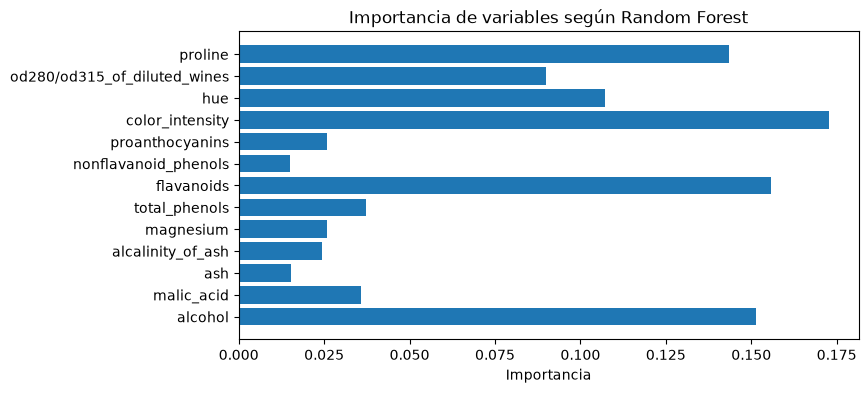

In [14]:
# Importancia de características para Random Forest
importancias = results['Random Forest']['model'].feature_importances_
plt.figure(figsize=(8,4))
plt.barh(df.columns[:-1], importancias)
plt.title('Importancia de variables según Random Forest')
plt.xlabel('Importancia')
plt.show()